In [1]:
import scipy.signal as sg
import numpy as np
def fourier_tr_padding(x, y):
    N = len(x)
    offset_init = np.mean(y)
    y_n = y - offset_init
    n_padding = 100
    freq_fft = np.fft.fftfreq(N*n_padding, (x[1]-x[0]))
    data_fft = np.fft.fft(np.concatenate([y_n, [0]*N*(n_padding-1)]))
    sorted_idx = np.argsort(freq_fft)
    freq_fft = freq_fft[sorted_idx]
    data_fft = data_fft[sorted_idx]
    return freq_fft, data_fft

def start_stop(x, y, xstart, xstop):
    x_list = np.array([el for el in x if el>=xstart and el<=xstop])
    x_idx = [i for i, el in enumerate(x) if el>=xstart and el<=xstop]
    y_list = y[x_idx]
    return x_list, y_list

def lowpass(t, x, fp, fs, gpass, gstop):
    samplerate = 1/(t[1]-t[0])
    fn = samplerate / 2                      
    wp = fp / fn                             
    ws = fs / fn                             
    N, Wn = sg.buttord(wp, ws, gpass, gstop) 
    b, a = sg.butter(N, Wn, "low")           
    y = sg.filtfilt(b, a, x)                 
    return y

def demodulate(t, data, demodulation_if = 0.125):
    return (data * np.exp(2j * np.pi * demodulation_if * t)).mean(axis=-1)

# spatiotempioral mode

### secant hyperbolic function

In [2]:
from scipy.special import gamma, zeta
import matplotlib.pyplot as plt

kappa = 2.5e-3*2*np.pi*2

def N_m(m, kappa=kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

# A_list[m] has the coefficients of A_m(t)([a0, a1, ..., am] (t^0, t^1, ..., t^m))
A_list = {}
Z_list = {}

A_list[0] = [1.0]
Z_dict = {
    0: kappa / 4,
    }

def compute_Z_m(m, A_coeffs):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = N_m(Nj_index)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1/Z

def get_A_m(m):
    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = get_A_m(lower_m)

        # sum over j
        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = N_m(m - (i + j))
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = compute_Z_m(m, A_m_coeffs)
    print("Z_m", Z_m, m, A_m_coeffs)
    Z_dict[m] = Z_m

    A_list[m] = A_m_coeffs
    return A_m_coeffs

In [23]:
for m in range(5):
    coeffs = get_A_m(m)
    poly_str = " + ".join(f"{c:.3f} t^{i}" for i, c in enumerate(coeffs) if abs(c) > 1e-10)
    print(f"A_{m}(t) =", poly_str)

A_0(t) = 1.000 t^0
Z_m 2.3561944901923456e-06 1 [0.0, 1.0]
A_1(t) = 1.000 t^1
Z_m 2.2089323345553242e-10 2 [-3333.3333333333326, 0.0, 1.0]
A_2(t) = -3333.333 t^0 + 1.000 t^2
Z_m 9.54476934684399e-15 3 [0.0, -13999.999999999998, 0.0, 1.0]
A_3(t) = -14000.000 t^1 + 1.000 t^3
Z_m 2.348908081449889e-19 4 [77142857.14285716, 0.0, -37142.85714285715, 0.0, 1.0]
A_4(t) = 77142857.143 t^0 + -37142.857 t^2 + 1.000 t^4


Z_m 2.3561944901923456e-06 1 [0.0, 1.0]
Z_m 2.2089323345553242e-10 2 [-3333.3333333333326, 0.0, 1.0]
Z_m 9.54476934684399e-15 3 [0.0, -13999.999999999998, 0.0, 1.0]
Z_m 2.348908081449889e-19 4 [77142857.14285716, 0.0, -37142.85714285715, 0.0, 1.0]
Z_m 3.7206704010166296e-24 5 [0.0, 646031746.0317459, 0.0, -77777.77777777778, 0.0, 1.0]
Z_m 4.1053693468007393e-29 6 [-4870129870129.864, 0.0, 2990909090.909087, 0.0, -140909.0909090908, 0.0, 1.0]
Z_m 3.3342233345529004e-34 7 [0.0, -63419580419580.66, 0.0, 10039860139.86017, 0.0, -231538.46153846185, 0.0, 1.0]
Z_m 2.0757493904076642e-39 8 [5.99650349650344e+17, 0.0, -431684848484845.1, 0.0, 27389743589.743458, 0.0, -354666.666666666, 0.0, 1.0]
Z_m 1.0218976575242988e-44 9 [0.0, 1.0786575894693693e+19, 0.0, -2044361990950247.5, 0.0, 64581176470.588585, 0.0, -515294.1176470599, 0.0, 1.0]


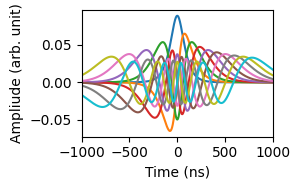

In [3]:
def sech(x):
    return 1 / np.cosh(x)

def xi_m(t, m, kappa):
    A_coeffs = get_A_m(m)
    Zm = Z_dict[m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

duration = 2000
t_vals = np.linspace(-duration/2, duration/2, duration)

plt.figure(figsize=(3, 2))

for m in range(10):
    y_vals = [xi_m(t, m, kappa) for t in t_vals]
    plt.plot(t_vals, y_vals, label=f'm={m}')

plt.xlabel('Time (ns)')
plt.ylabel('Ampliude (arb. unit)')
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.xlim(-duration/2, duration/2)
# plt.savefig("Figapp2_a.pdf")
# plt.savefig("Figapp2_a_25.pdf")
plt.show()

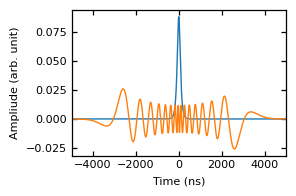

In [21]:


duration = 10000
t_vals = np.linspace(-duration/2, duration/2, duration)

plt.figure(figsize=(3, 2))
y_vals = [xi_m(t, 0, kappa) for t in t_vals]
plt.plot(t_vals, y_vals, label=f'm={m}')
y_vals = [xi_m(t, 49, kappa) for t in t_vals]
plt.plot(t_vals, y_vals, label=f'm={m}')

plt.xlabel('Time (ns)')
plt.ylabel('Ampliude (arb. unit)')
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.xlim(-duration/2, duration/2)
# plt.xlim(-500, 500)
# plt.savefig("Figapp2_a.pdf")
# plt.savefig("Figapp2_a_25.pdf")
plt.show()

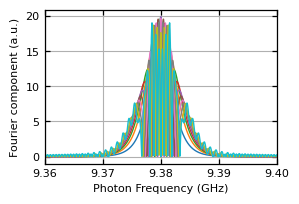

In [25]:

readout_lo_freq = 9.5
target_freq = 9.38
duration = 2000
t_vals = np.linspace(-duration/2, duration/2, duration)
xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(10)]

plt.figure(figsize=(3, 2))
for label, waveform in enumerate(xi_funcs_s):
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    plt.plot(photon_freq, np.abs(fourier), label=f'm={label}')

plt.xlabel("Photon Frequency (GHz)")
plt.ylabel("Fourier component (a.u.)")
plt.xlim(9.36, 9.4)
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.show()

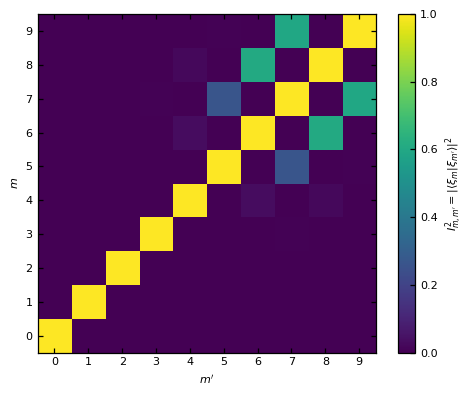

In [26]:
from scipy.integrate import quad

def inner_product(m1, m2, kappa, duraiton):
    func = lambda t: np.conjugate(xi_m(t, m1, kappa)) * xi_m(t, m2, kappa)
    result, _ = quad(func, -duration/2, duration/2)
    return result

def norm_of_xi(m, kappa, duration):
    func = lambda t: np.abs(xi_m(t, m, kappa))**2
    result, _ = quad(func, -duration/2, duration/2)
    return np.sqrt(result)

n_max = 9
gram_matrix = np.zeros((n_max + 1, n_max + 1))
I_normalized = np.zeros((n_max + 1, n_max + 1))

duration = 1000
for m1 in range(n_max + 1):
    for m2 in range(n_max + 1):
        gram_matrix[m1, m2] = inner_product(m1, m2, kappa, duration)
        norm_product = norm_of_xi(m1, kappa, duration)*norm_of_xi(m2, kappa, duration)
        I_normalized[m1, m2] = gram_matrix[m1, m2] / norm_product
        

plt.figure(figsize=(5, 4))
im = plt.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
plt.colorbar(im, label=r'$I_{m,m^{\prime}}^2=|\langle \xi_m | \xi_{m^{\prime}} \rangle|^2$')
plt.xlabel(r"$m'$")
plt.ylabel(r"$m$")
plt.xticks(np.arange(n_max + 1))
plt.yticks(np.arange(n_max + 1))
plt.grid(False)
plt.tight_layout()
plt.show()


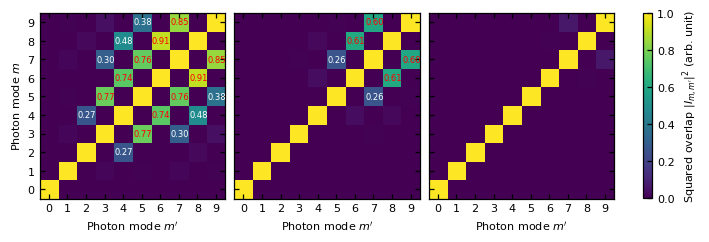

In [27]:
n_max = 9
durations = [500, 1000, 1500]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True, constrained_layout=True)

for idx, duration in enumerate(durations):
    gram_matrix = np.zeros((n_max + 1, n_max + 1))
    I_normalized = np.zeros((n_max + 1, n_max + 1))
    for m1 in range(n_max + 1):
        for m2 in range(n_max + 1):
            gram_matrix[m1, m2] = inner_product(m1, m2, kappa, duration)
            norm_product = norm_of_xi(m1, kappa, duration)*norm_of_xi(m2, kappa, duration)
            I_normalized[m1, m2] = gram_matrix[m1, m2] / norm_product
        

    ax = axes[idx]
    im = ax.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
    ax.set_xlabel(r"Photon mode $m^{\prime}$")
    ax.set_xticks(np.arange(n_max + 1))
    if idx == 0:
        ax.set_ylabel(r"Photon mode $m$")
        ax.set_yticks(np.arange(n_max + 1))

    for i in range(n_max + 1):
        for j in range(n_max + 1):
            text = f"{(I_normalized[i, j]**2):.2f}"
            if I_normalized[i, j]**2 > 0.1 and I_normalized[i, j]**2 < 0.99:
                if I_normalized[i, j]**2 > 0.5:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='red', fontsize=6)
                else:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='white', fontsize=6)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right')
cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$ (arb. unit)')
# plt.savefig("Figapp3_a_25.pdf", bbox_inches='tight')
plt.show()


### Hermite function

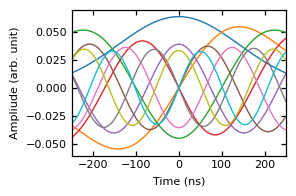

In [8]:
from scipy.special import eval_hermite, factorial

def hermite(x, n, kappa):
    x_scaled = np.sqrt(kappa) * x
    norm = np.sqrt(np.sqrt(kappa / np.pi)) / np.sqrt(2**n * factorial(n))
    psi = norm * eval_hermite(n, x_scaled) * np.exp(-x_scaled**2 / 2)
    return psi

kappa = 4.e-6*2*np.pi*2
duration = 500
t_vals = np.linspace(-duration/2, duration/2, duration)

plt.figure(figsize=(3, 2))

for m in range(10):
    y_vals =hermite(t_vals, m, kappa)
    plt.plot(t_vals, y_vals, label=f'm={m}')

plt.xlabel('Time (ns)')
plt.ylabel('Ampliude (arb. unit)')
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
plt.xlim(-duration/2, duration/2)
# plt.savefig("Figapp2_a.pdf")
# plt.savefig("Figapp2_a_tw.pdf")
plt.show()

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


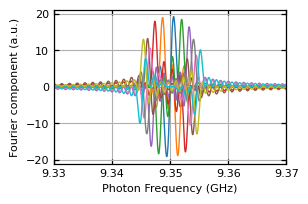

In [9]:

readout_lo_freq = 9.5
target_freq = 9.35
duration = 750
t_vals = np.linspace(-duration/2, duration/2, duration)
xi_funcs_sh = [hermite(t_vals, m, kappa) for m in range(10)]

plt.figure(figsize=(3, 2))
for label, waveform in enumerate(xi_funcs_sh):
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    plt.plot(photon_freq, fourier, label=f'm={label}')

plt.xlabel("Photon Frequency (GHz)")
plt.ylabel("Fourier component (a.u.)")
plt.xlim(9.33, 9.37)
# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.show()

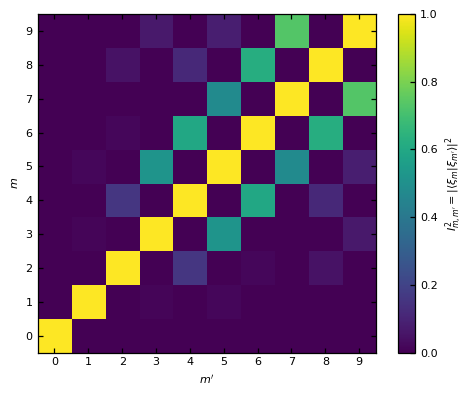

In [10]:
from scipy.integrate import quad

def inner_product_he(m1, m2, kappa, duration):
    func = lambda t: np.conjugate(hermite(t, m1, kappa)) * hermite(t, m2, kappa)
    result, _ = quad(func, -duration/2, duration/2)
    return result

def norm_of_xi_he(m, kappa, duration):
    func = lambda t: np.abs(hermite(t, m, kappa))**2
    result, _ = quad(func, -duration/2, duration/2)
    return np.sqrt(result)

n_max = 9
gram_matrix = np.zeros((n_max + 1, n_max + 1))
I_normalized = np.zeros((n_max + 1, n_max + 1))

duration = 600
for m1 in range(n_max + 1):
    for m2 in range(n_max + 1):
        gram_matrix[m1, m2] = inner_product_he(m1, m2, kappa, duration)
        norm_product = norm_of_xi_he(m1, kappa, duration)*norm_of_xi_he(m2, kappa, duration)
        I_normalized[m1, m2] = gram_matrix[m1, m2] / norm_product
        

plt.figure(figsize=(5, 4))
im = plt.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
plt.colorbar(im, label=r'$I_{m,m^{\prime}}^2=|\langle \xi_m | \xi_{m^{\prime}} \rangle|^2$')
plt.xlabel(r"$m'$")
plt.ylabel(r"$m$")
plt.xticks(np.arange(n_max + 1))
plt.yticks(np.arange(n_max + 1))
plt.grid(False)
plt.tight_layout()
plt.show()


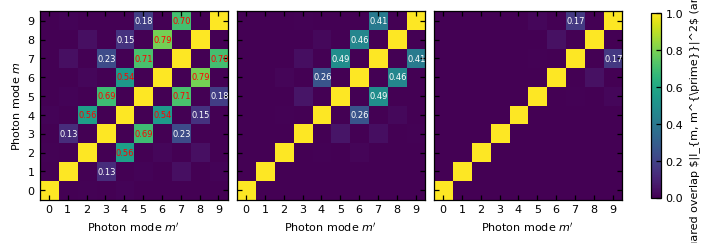

In [11]:
n_max = 9
durations = [500, 750, 1000]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True, constrained_layout=True)

for idx, duration in enumerate(durations):
    gram_matrix = np.zeros((n_max + 1, n_max + 1))
    I_normalized = np.zeros((n_max + 1, n_max + 1))
    for m1 in range(n_max + 1):
        for m2 in range(n_max + 1):
            gram_matrix[m1, m2] = inner_product_he(m1, m2, kappa, duration)
            norm_product = norm_of_xi_he(m1, kappa, duration)*norm_of_xi_he(m2, kappa, duration)
            I_normalized[m1, m2] = gram_matrix[m1, m2] / norm_product
        

    ax = axes[idx]
    im = ax.imshow(I_normalized**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
    ax.set_xlabel(r"Photon mode $m^{\prime}$")
    ax.set_xticks(np.arange(n_max + 1))
    if idx == 0:
        ax.set_ylabel(r"Photon mode $m$")
        ax.set_yticks(np.arange(n_max + 1))

    for i in range(n_max + 1):
        for j in range(n_max + 1):
            text = f"{(I_normalized[i, j]**2):.2f}"
            if I_normalized[i, j]**2 > 0.1 and I_normalized[i, j]**2 < 0.99:
                if I_normalized[i, j]**2 > 0.5:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='red', fontsize=6)
                else:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='white', fontsize=6)

cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right')
cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2$ (arb. unit)$')
# plt.savefig("Figapp3_a.pdf", bbox_inches='tight')
plt.show()


# Gaussian filter

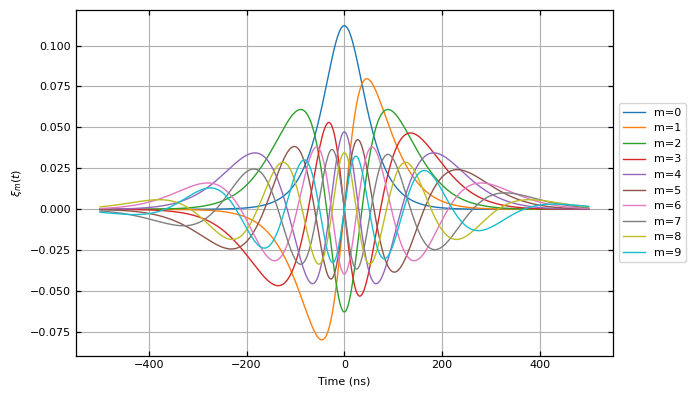

In [47]:
from scipy.signal import windows

sigma = duration / 5
gaussian_window = windows.gaussian(duration, std=sigma)

plt.figure(figsize=(7, 4))

for m in range(10):
    y_vals = np.array([xi_m(t, m, kappa) for t in t_vals])
    y_vals *= gaussian_window
    plt.plot(t_vals, y_vals, label=f'm={m}')

plt.xlabel('Time (ns)')
plt.ylabel(r'$\xi_m(t)$')
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

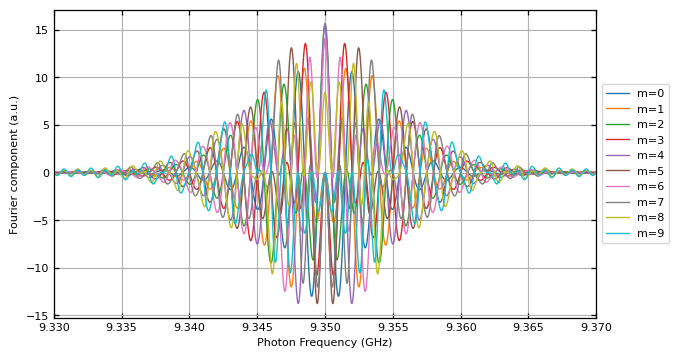

In [48]:
readout_lo_freq = 9.5
target_freq = 9.35
xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(10)]

plt.figure(figsize=(7, 4))
for label, waveform in enumerate(xi_funcs_s):
    # waveform *= gaussian_window
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    plt.plot(photon_freq, fourier, label=f'm={label}')

plt.xlabel("Photon Frequency (GHz)")
plt.ylabel("Fourier component (a.u.)")
plt.xlim(9.33, 9.37)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_8572\1616257093.py:16: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(func, -duration/2, duration/2, limit=200)


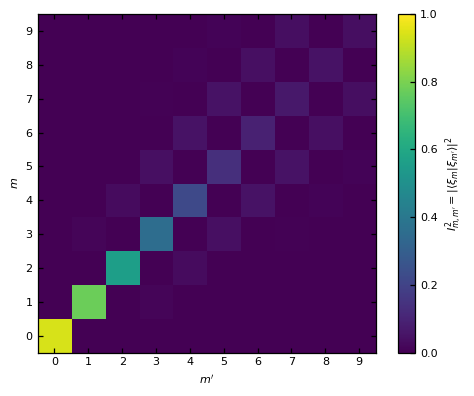

In [49]:
from scipy.interpolate import interp1d

def xi_m_windowed(t, m, kappa):
    A_coeffs = get_A_m(m)
    Zm = Z_dict[m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

def inner_product_windowed(m1, m2, kappa):
    interp_window = interp1d(t_vals, gaussian_window, kind='linear', bounds_error=False, fill_value=0.0)

    def func(t):
        w = interp_window(t)
        return np.conjugate(xi_m_windowed(t, m1, kappa)) * xi_m_windowed(t, m2, kappa) * w**2

    result, _ = quad(func, -duration/2, duration/2, limit=200)
    return result

for m1 in range(n_max + 1):
    for m2 in range(n_max + 1):
        gram_matrix[m1, m2] = np.abs(inner_product_windowed(m1, m2, kappa))**2

plt.figure(figsize=(5, 4))
im = plt.imshow(gram_matrix, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
plt.colorbar(im, label=r'$I_{m,m^{\prime}}^2=|\langle \xi_m | \xi_{m^{\prime}} \rangle|^2$')
plt.xlabel(r"$m'$")
plt.ylabel(r"$m$")
plt.xticks(np.arange(n_max + 1))
plt.yticks(np.arange(n_max + 1))
plt.grid(False)
plt.tight_layout()
plt.show()

# time-bin mode

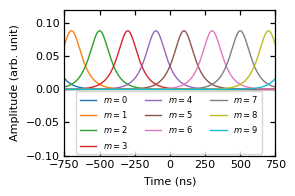

In [31]:
m_tot = 10
duration = 2000
t_vals = np.linspace(-duration/2, duration/2, duration)

def xi_m_shifted(t, m, m_tot, kappa):
    shift = duration * (2 * m + 1 - m_tot) / (2 * m_tot)
    return xi_m(t - shift, 0, kappa)

def norm_of_xi_shifted(m, m_tot, kappa, duration):
    func = lambda t: np.abs(xi_m_shifted(t, m, m_tot, kappa))**2
    result, _ = quad(func, -duration/2, duration/2)
    return np.sqrt(result)

xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]


fig, ax = plt.subplots(1, 1, figsize=(3, 2))
for m, y_vals in enumerate(xi_funcs_t):
    ax.plot(t_vals, y_vals, label=f'$m={m}$')
ax.set_xlabel('Time (ns)')
ax.set_ylim(-0.1, 0.12)
ax.set_xlim(-750, 750)
ax.set_ylabel('Amplitude (arb. unit)')

fig.legend(loc='lower center', bbox_to_anchor=(0.57, 0.2), ncol=3, fontsize=6)
# plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# plt.savefig("Figapp3_b.pdf", bbox_inches='tight')
# plt.savefig("Figapp3_b_25.pdf", bbox_inches='tight')
plt.show()

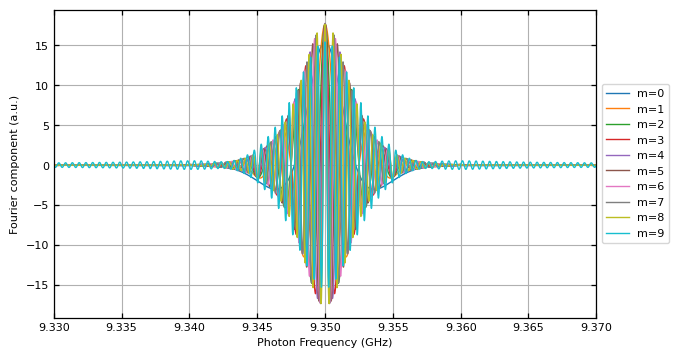

In [32]:
readout_lo_freq = 9.5
target_freq = 9.35
plt.figure(figsize=(7, 4))


for label, waveform in enumerate(xi_funcs_t):
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    plt.plot(photon_freq, fourier, label=f'm={label}')

plt.xlabel("Photon Frequency (GHz)")
plt.ylabel("Fourier component (a.u.)")
plt.xlim(9.33, 9.37)
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.show()

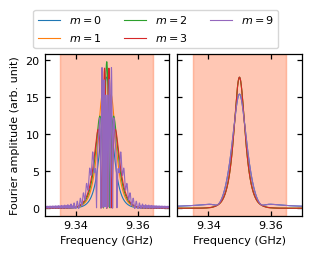

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(3, 2), sharey=True, constrained_layout=True)

for label, waveform in enumerate(xi_funcs_s):
    if label not in [0, 1, 2, 3, 9]:
        continue
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    axes[0].plot(photon_freq, np.abs(fourier), label=f'$m={label}$', linewidth=0.8)
    axes[0].set_xlim(9.33, 9.37)
    axes[0].axvspan(9.335, 9.365, color="coral", alpha=0.1)

for label, waveform in enumerate(xi_funcs_t):
    if label not in [0, 1, 2, 3, 9]:
        continue
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    axes[1].plot(photon_freq, np.abs(fourier), linewidth=0.8)
    axes[1].set_xlim(9.33, 9.37)
    axes[1].axvspan(9.335, 9.365, color="coral", alpha=0.1)

axes[0].set_ylabel(r"Fourier amplitude (arb. unit)")
axes[0].set_xlabel(r"Frequency (GHz)")
axes[1].set_xlabel(r"Frequency (GHz)")

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.23), ncol=3)
# cbar = fig.colorbar(im, ax=axes, shrink=0.9, location='right')
# cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2 (arb. unit)$')
# plt.savefig("Figapp3_c_25.pdf", bbox_inches='tight')
plt.show()


C:\Users\qipe\AppData\Local\Temp\ipykernel_14124\2067425849.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  I_normalized[m1, m2] = gram_matrix[m1, m2] / norm_product


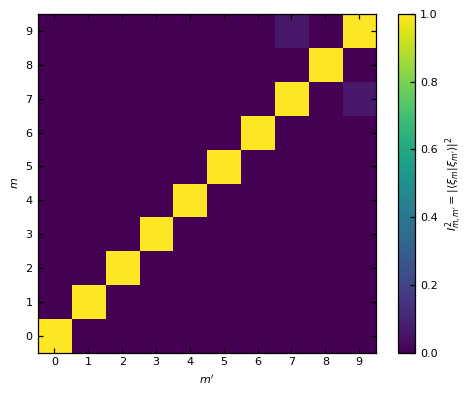

In [35]:
gram_matrix = np.zeros((m_tot, m_tot), dtype=complex)
for i in range(m_tot):
    for j in range(m_tot):
        t_vals = np.linspace(-duration/2, duration/2, duration)
        xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]
        integrand = np.conj(xi_funcs_t[i]) * xi_funcs_t[j]
        gram_matrix[i, j] = np.trapz(integrand, t_vals)
        norm_product = norm_of_xi_shifted(m1, m_tot, kappa, duration)*norm_of_xi_shifted(m2, m_tot, kappa, duration)
        I_normalized[m1, m2] = gram_matrix[m1, m2] / norm_product

plt.figure(figsize=(5, 4))
im = plt.imshow(np.abs(I_normalized)**2, cmap='viridis', origin='lower', vmin=0, vmax=1)
plt.colorbar(im, label=r'$I_{m,m^{\prime}}^2=|\langle \xi_m | \xi_{m^{\prime}} \rangle|^2$')
plt.xlabel(r"$m'$")
plt.ylabel(r"$m$")
plt.xticks(np.arange(m_tot))
plt.yticks(np.arange(m_tot))
plt.tight_layout()
plt.show()

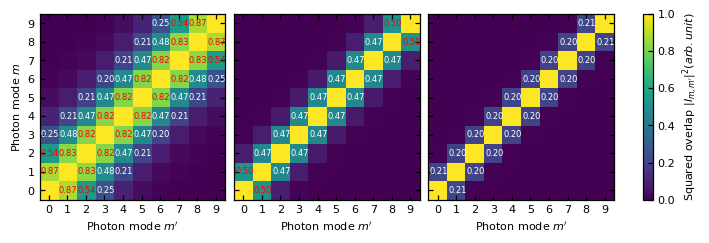

In [36]:
n_max = 9
durations = [500, 1000, 1500]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True, constrained_layout=True)

for idx, duration in enumerate(durations):
    gram_matrix = np.zeros((n_max + 1, n_max + 1))
    for m1 in range(n_max + 1):
        for m2 in range(n_max + 1):
            t_vals = np.linspace(-duration/2, duration/2, duration)
            xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]
            integrand = np.conj(xi_funcs_t[m1]) * xi_funcs_t[m2]
            gram_matrix[m1, m2] = np.trapz(integrand, t_vals)
            norm_product = norm_of_xi_shifted(m1, m_tot, kappa, duration)*norm_of_xi_shifted(m2, m_tot, kappa, duration)
            I_normalized[m1, m2] = gram_matrix[m1, m2] / norm_product
            

    ax = axes[idx]
    im = ax.imshow(np.abs(I_normalized)**2, cmap='viridis', interpolation='nearest', origin='lower', vmin=0, vmax=1)
    ax.set_xlabel(r"Photon mode $m^{\prime}$")
    ax.set_xticks(np.arange(n_max + 1))
    if idx == 0:
        ax.set_ylabel(r"Photon mode $m$")
        ax.set_yticks(np.arange(n_max + 1))

    for i in range(n_max + 1):
        for j in range(n_max + 1):
            text = f"{(I_normalized[i, j]**2):.2f}"
            if I_normalized[i, j]**2 > 0.1 and I_normalized[i, j]**2 < 0.99:
                if I_normalized[i, j]**2 > 0.5:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='red', fontsize=6)
                else:
                    ax.text(j+0.05, i, text, ha='center', va='center', color='white', fontsize=6)



cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right')
cbar.set_label(label=r'Squared overlap $|I_{m, m^{\prime}}|^2 (arb. unit)$')
# plt.savefig("Figapp3_d_25.pdf", bbox_inches='tight')
plt.show()


## compute orthogonality

### old metrix

In [17]:
def compute_orthogonality_metrics(xi_funcs, t_vals):
    M = len(xi_funcs)
    gram = np.zeros((M, M), dtype=np.complex128)

    for i in range(M):
        for j in range(M):
            gram[i, j] = np.trapz(np.conj(xi_funcs[i]) * xi_funcs[j], x=t_vals)

    identity = np.eye(M)
    epsilon_frob = np.linalg.norm(gram - identity)
    return epsilon_frob

metrics = compute_orthogonality_metrics(xi_funcs_t, t_vals)
print(metrics)

1.7562601550507546


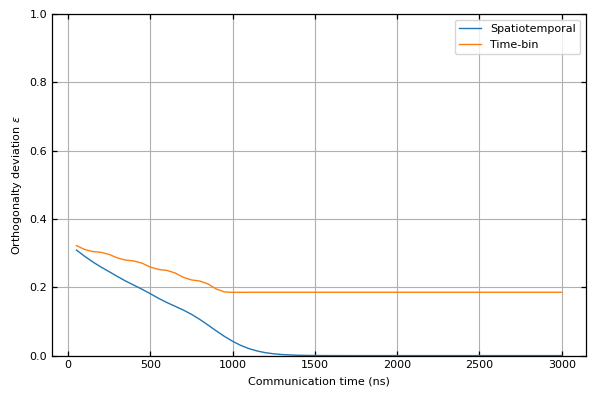

In [18]:
def compute_orthogonality_and_xi_for_durations(duration_list, kappa):
    orthogonality_changes_s = {}
    orthogonality_changes_t = {}
    
    for duration in duration_list:
        duration_int = int(duration)
        t_vals = np.linspace(-duration_int/2, duration_int/2, duration_int)
        
        xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(m_tot)]
        xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]
        
        frob_max = np.sqrt(m_tot * (m_tot - 1))
        metrics_s = compute_orthogonality_metrics(xi_funcs_s, t_vals)/frob_max
        metrics_t = compute_orthogonality_metrics(xi_funcs_t, t_vals)/frob_max
        orthogonality_changes_s[duration] = metrics_s
        orthogonality_changes_t[duration] = metrics_t

    return orthogonality_changes_s, orthogonality_changes_t

duration_list = np.linspace(50, 3000, 60)
orthogonality_changes_s, orthogonality_changes_t = compute_orthogonality_and_xi_for_durations(duration_list, kappa)


plt.figure(figsize=(6, 4))
plt.plot(duration_list, [orthogonality_changes_s[duration] for duration in duration_list], label="Spatiotemporal")
plt.plot(duration_list, [orthogonality_changes_t[duration] for duration in duration_list], label="Time-bin")

plt.xlabel("Communication time (ns)")
plt.ylabel(r"Orthogonalty deviation $\epsilon$")
plt.legend()
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


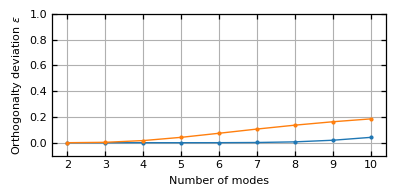

In [19]:
def compute_orthogonality_vs_mode(m_range, duration, kappa):
    orthogonality_s = []
    orthogonality_t = []

    t_vals = np.linspace(-duration/2, duration/2, int(duration))

    for m_tot in m_range:
        xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(m_tot)]
        xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]

        frob_max = np.sqrt(m_tot * (m_tot - 1))
        frob_s = compute_orthogonality_metrics(xi_funcs_s, t_vals)/frob_max
        frob_t = compute_orthogonality_metrics(xi_funcs_t, t_vals)/frob_max

        orthogonality_s.append(frob_s)
        orthogonality_t.append(frob_t)

    return orthogonality_s, orthogonality_t

duration_fixed = 1000
m_range = np.arange(2, 11)

orthogonality_s, orthogonality_t = compute_orthogonality_vs_mode(m_range, duration_fixed, kappa)

plt.figure(figsize=(4, 2))
plt.plot(m_range, orthogonality_s, 'o-', label="Spatiotemporal")
plt.plot(m_range, orthogonality_t, 'o-', label="Time-bin")

plt.xlabel("Number of modes")
plt.ylabel(r"Orthogonalty deviation $\epsilon$")
# plt.plot(m_range, frob_max, '--', label="Worst case")
plt.xticks(m_range)
plt.ylim(-0.1, 1)
# plt.legend()
plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# plt.savefig("Fig4_a.pdf")
plt.show()


Z_m 7.886783788972487e-46 10 [-1.1078112728398678e+21, 0.0, 2.292762418433125e+18, 0.0, -453469553968130.06, 0.0, 20847096162.68425, 0.0, -280633.2236842133, 0.0, 1.0]
Z_m 6.660645051147909e-51 11 [0.0, -2.5695113594879328e+22, 0.0, 1.4222339316036395e+19, 0.0, -1418215940611140.0, 0.0, 40553272218.62985, 0.0, -378534.226190464, 0.0, 1.0]
Z_m 4.728235684459329e-56 12 [1.3117450218081231e+26, 0.0, -2.9717815067019754e+23, 0.0, 6.791708358726839e+19, 0.0, -3886693675131302.5, 0.0, 73782689823.13443, 0.0, -496942.9347826323, 0.0, 1.0]
Z_m 2.8606810905566532e-61 13 [0.0, 3.75083398250104e+27, 0.0, -2.3006729064934168e+24, 0.0, 2.677005465254314e+20, 0.0, -9599415500709360.0, 0.0, 127106641686.46089, 0.0, -637812.4999999569, 0.0, 1.0]
Z_m 1.4926535902766948e-66 14 [-2.168098933326799e+31, 0.0, 5.286949811037855e+28, 0.0, -1.3526250593630363e+25, 0.0, 9.101071324947512e+20, 0.0, -2.179448149631067e+16, 0.0, 209243141456.92212, 0.0, -803096.0648148718, 0.0, 1.0]


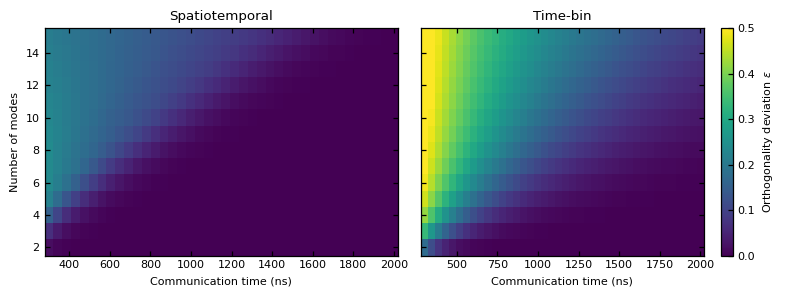

In [20]:
duration_list = np.linspace(300, 2000, 40)
m_range = np.arange(2, 16)

epsilon_s_map = np.zeros((len(m_range), len(duration_list)))
epsilon_t_map = np.zeros((len(m_range), len(duration_list)))

for i, m_tot in enumerate(m_range):
    for j, duration in enumerate(duration_list):
        t_vals = np.linspace(-duration/2, duration/2, int(duration))
        
        xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(m_tot)]
        xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]

        frob_max = np.sqrt(m_tot * (m_tot - 1))
        epsilon_s = compute_orthogonality_metrics(xi_funcs_s, t_vals) / frob_max
        epsilon_t = compute_orthogonality_metrics(xi_funcs_t, t_vals) / frob_max

        epsilon_s_map[i, j] = epsilon_s
        epsilon_t_map[i, j] = epsilon_t


X, Y = np.meshgrid(duration_list, m_range)

fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
axs[0].set_title("Spatiotemporal")
axs[0].set_xlabel("Communication time (ns)")
axs[0].set_ylabel("Number of modes")
# fig.colorbar(c1, ax=axs[0], label=r"Orthogonality deviation $\epsilon$")

# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_t_map, shading='auto', cmap='viridis', vmin=0, vmax=0.5)
axs[1].set_title("Time-bin")
axs[1].set_xlabel("Communication time (ns)")
fig.colorbar(c2, ax=axs[1], label=r"Orthogonality deviation $\epsilon$")

plt.tight_layout()
plt.show()


In [21]:
from scipy.linalg import sqrtm
def compute_orthogonality_fidelity(xi_funcs, t_vals):
    M = len(xi_funcs)
    gram = np.zeros((M, M), dtype=np.complex128)

    for i in range(M):
        for j in range(M):
            gram[i, j] = np.trapz(np.conj(xi_funcs[i]) * xi_funcs[j], x=t_vals)

    # Define normalized rho and sigma
    rho = gram / np.trace(gram)
    sigma = np.eye(M) / M

    # Fidelity: F = (Tr sqrt(sqrt(rho) sigma sqrt(rho)))^2
    sqrt_rho =sqrtm(rho)
    product = np.dot(sqrt_rho, np.dot(sigma, sqrt_rho))
    sqrt_product = sqrtm(product)
    fidelity = np.abs(np.trace(sqrt_product))**2
    return fidelity

In [21]:
def compute_orthogonality_and_xi_for_durations(duration_list, kappa):
    orthogonality_changes_s = {}
    orthogonality_changes_t = {}
    
    for duration in duration_list:
        duration_int = int(duration)
        t_vals = np.linspace(-duration_int/2, duration_int/2, duration_int)
        
        xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(m_tot)]
        xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]
        
        metrics_s = compute_orthogonality_fidelity(xi_funcs_s, t_vals)
        metrics_t = compute_orthogonality_fidelity(xi_funcs_t, t_vals)
        orthogonality_changes_s[duration] = metrics_s
        orthogonality_changes_t[duration] = metrics_t

    return orthogonality_changes_s, orthogonality_changes_t

duration_list = np.linspace(50, 3000, 60)
orthogonality_changes_s, orthogonality_changes_t = compute_orthogonality_and_xi_for_durations(duration_list, kappa)


plt.figure(figsize=(6, 4))
plt.plot(duration_list, [orthogonality_changes_s[duration] for duration in duration_list], label="Spatiotemporal")
plt.plot(duration_list, [orthogonality_changes_t[duration] for duration in duration_list], label="Time-bin")

plt.xlabel("Communication time (ns)")
plt.ylabel(r"Orthogonalty fidelity $F$")
plt.legend()
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'compute_orthogonality_fidelity' is not defined

In [22]:
def compute_orthogonality_vs_mode(m_range, duration, kappa):
    orthogonality_s = []
    orthogonality_t = []

    t_vals = np.linspace(-duration/2, duration/2, int(duration))

    for m_tot in m_range:
        xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(m_tot)]
        xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]

        frob_s = compute_orthogonality_fidelity(xi_funcs_s, t_vals)
        frob_t = compute_orthogonality_fidelity(xi_funcs_t, t_vals)

        orthogonality_s.append(frob_s)
        orthogonality_t.append(frob_t)

    return orthogonality_s, orthogonality_t

duration_fixed = 1000
m_range = np.arange(2, 11)

orthogonality_s, orthogonality_t = compute_orthogonality_vs_mode(m_range, duration_fixed, kappa)

plt.figure(figsize=(4, 2))
plt.plot(m_range, orthogonality_s, 'o-', label="Spatiotemporal")
plt.plot(m_range, orthogonality_t, 'o-', label="Time-bin")

plt.xlabel("Number of modes")
plt.ylabel(r"Orthogonalty fidelityn $F$")
# plt.plot(m_range, frob_max, '--', label="Worst case")
plt.xticks(m_range)
plt.ylim(-0.1, 1)
# plt.legend()
plt.grid(True)
plt.tight_layout()
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# plt.savefig("Fig4_a.pdf")
plt.show()


NameError: name 'compute_orthogonality_fidelity' is not defined

In [23]:
duration_list = np.linspace(500, 2000, 50)
m_range = np.arange(2, 20)

epsilon_s_map = np.zeros((len(m_range), len(duration_list)))
epsilon_t_map = np.zeros((len(m_range), len(duration_list)))

for i, m_tot in enumerate(m_range):
    for j, duration in enumerate(duration_list):
        t_vals = np.linspace(-duration/2, duration/2, int(duration))
        
        xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(m_tot)]
        xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]

        epsilon_s = compute_orthogonality_fidelity(xi_funcs_s, t_vals) 
        epsilon_t = compute_orthogonality_fidelity(xi_funcs_t, t_vals) 

        epsilon_s_map[i, j] = epsilon_s
        epsilon_t_map[i, j] = epsilon_t


X, Y = np.meshgrid(duration_list, m_range)

fig, axs = plt.subplots(2, 1, figsize=(3.2, 2.8), sharex=True, sharey=True, constrained_layout=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# axs[0].set_title("Spatiotemporal")
# axs[0].set_xlabel("Communication time (ns)")
axs[0].set_ylabel("Number of modes $M$")
# fig.colorbar(c1, ax=axs[0], label=r"Basis fidelity $F(M)$")

# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_t_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# axs[1].set_title("Time-bin")
axs[1].set_xlabel("Communication time (ns)")
axs[1].set_ylabel("Number of modes $M$")
fig.colorbar(c2, ax=axs, label=r"Basis fidelity $F(M)$")
# plt.savefig('Fig4_a.pdf', bbox_inches='tight')

plt.show()
target_M = 10
target_durations = [500, 1000, 1500]

i_M = np.where(m_range == target_M)[0][0]


for duration in target_durations:
    j_dur = np.argmin(np.abs(duration_list - duration))
    
    fidelity_s = epsilon_s_map[i_M, j_dur]
    fidelity_t = epsilon_t_map[i_M, j_dur]
    
    print(f"M = {target_M}, Communication time = {duration} ns")
    print(f"  Spatiotemporal fidelity : {fidelity_s:.4f}")
    print(f"  Time-bin fidelity       : {fidelity_t:.4f}")
    print("-" * 50)

NameError: name 'compute_orthogonality_fidelity' is not defined

### separability

In [37]:
def compute_separability(xi_funcs, t_vals):
    M = len(xi_funcs)
    gram = np.zeros((M, M), dtype=np.complex128)

    for i in range(M):
        for j in range(M):
            gram[i, j] = np.trapz(np.conj(xi_funcs[i]) * xi_funcs[j], x=t_vals)

    S_list = []
    for m in range(M):
        numerator = np.abs(gram[m, m])**2
        denominator = np.sum(np.abs(gram[m, :])**2)
        S_list.append(numerator / denominator)
    return np.mean(S_list) 


Z_m 4.077371653521792e-50 10 [-1.2180513758686839e+23, 0.0, 9.847339604667594e+19, 0.0, -7607956656346659.0, 0.0, 136623529411.76384, 0.0, -718421.0526315769, 0.0, 1.0]
Z_m 1.345106556007919e-55 11 [0.0, -2.825207617460148e+24, 0.0, 6.108448223500302e+20, 0.0, -2.379371517027971e+16, 0.0, 265769924812.03833, 0.0, -969047.6190476349, 0.0, 1.0]
Z_m 3.729920282138782e-61 12 [3.6922339946360564e+28, 0.0, -3.2675083218273307e+25, 0.0, 2.9170165284693323e+21, 0.0, -6.520789931349824e+16, 0.0, 483542236024.8305, 0.0, -1272173.91304346, 0.0, 1.0]
Z_m 8.81515419784242e-67 13 [0.0, 1.0557659078707675e+30, 0.0, -2.5296166124001544e+26, 0.0, 1.1497650924485222e+22, 0.0, -1.6105146732919053e+17, 0.0, 833006086956.5013, 0.0, -1632799.999999963, 0.0, 1.0]
Z_m 1.7967164038146261e-72 14 [-1.5622799277138163e+34, 0.0, 1.488144074929407e+31, 0.0, -1.4872269807884837e+27, 0.0, 3.908880369916438e+22, 0.0, -3.6565072367128e+17, 0.0, 1371295851851.3027, 0.0, -2055925.9259255116, 0.0, 1.0]
Z_m 3.1906134262460

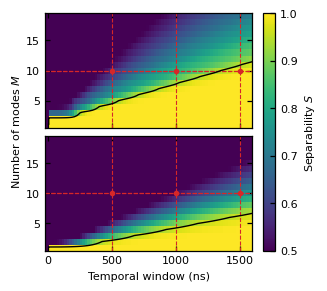

M = 10, Communication time = 500 ns
  Spatiotemporal separability : 0.5549
  Time-bin separability      : 0.2663
--------------------------------------------------
M = 10, Communication time = 1000 ns
  Spatiotemporal separability : 0.8122
  Time-bin separability      : 0.5048
--------------------------------------------------
M = 10, Communication time = 1500 ns
  Spatiotemporal separability : 0.9848
  Time-bin separability      : 0.7254
--------------------------------------------------


In [38]:
duration_list = np.linspace(0, 1800, 91)
m_range = np.arange(1, 20)

epsilon_s_map = np.zeros((len(m_range), len(duration_list)))
epsilon_t_map = np.zeros((len(m_range), len(duration_list)))

for i, m_tot in enumerate(m_range):
    for j, duration in enumerate(duration_list):
        if np.isclose(duration, 0):
            epsilon_s = 0
            epsilon_t = 0
        else:
            t_vals = np.linspace(-duration/2, duration/2, int(duration))
            
            xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(m_tot)]
            xi_funcs_t = [xi_m_shifted(t_vals, m, m_tot, kappa) for m in range(m_tot)]

            epsilon_s = compute_separability(xi_funcs_s, t_vals) 
            epsilon_t = compute_separability(xi_funcs_t, t_vals) 

        epsilon_s_map[i, j] = epsilon_s
        epsilon_t_map[i, j] = epsilon_t


X, Y = np.meshgrid(duration_list, m_range)

fig, axs = plt.subplots(2, 1, figsize=(3., 2.8), sharex=True, sharey=True, constrained_layout=True)

# Spatiotemporal
c1 = axs[0].pcolormesh(X, Y, epsilon_s_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# axs[0].set_title("Spatiotemporal")
# axs[0].set_xlabel("Communication time (ns)")
# axs[0].set_ylabel("Number of modes $M$")
# fig.colorbar(c1, ax=axs[0], label=r"Basis fidelity $F(M)$")
# Time-bin
c2 = axs[1].pcolormesh(X, Y, epsilon_t_map, shading='auto', cmap='viridis', vmin=0.5, vmax=1)
# axs[1].set_title("Time-bin")
axs[1].set_xlabel("Temporal window (ns)")
# axs[1].set_ylabel("Number of modes $M$")
fig.colorbar(c2, ax=axs, label=r"Separability $S$")
axs[0].set_xlim(-20, 1600)
axs[1].set_xlim(-20, 1600)
# === black line ===
target_M = 10
target_durations = [500, 1000, 1500]

i_M = np.where(m_range == target_M)[0][0]

for duration in target_durations:
    j_dur = np.argmin(np.abs(duration_list - duration))
    dur_val = duration_list[j_dur]
    for ax in axs:
        ax.axvline(x=dur_val, color='tab:red', linestyle='--', linewidth=0.8)
    for ax in axs:
        ax.axhline(y=target_M, color='tab:red', linestyle='--', linewidth=0.8)
    for ax, data_map in zip(axs, [epsilon_s_map, epsilon_t_map]):
            value = data_map[i_M, j_dur]
            ax.plot(dur_val, target_M, marker='o', color='tab:red', markersize=3)
for ax in axs:
    ax.set_yticks([0, 5, 10, 15, 20])

# === Separability = 0.95 ===

# contour_s = axs[0].contour(X-0.2, Y, epsilon_s_map, levels=[0.95], colors='black', linewidths=1.0)
# contour_t = axs[1].contour(X-0.2, Y, epsilon_t_map, levels=[0.95], colors='black', linewidths=1.0)
Xc = X[:, :-1] - np.diff(X, axis=1)/2  # center of each pcolormesh cell (x-direction)
Yc = Y[:, :-1]  # same shape as Xc (y-direction constant per row)

contour_s = axs[0].contour(Xc, Yc, epsilon_s_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
contour_t = axs[1].contour(Xc, Yc, epsilon_t_map[:, :-1], levels=[0.95], colors='black', linewidths=1.0)
fig.text(-0.04, 0.55, "Number of modes $M$", va="center", rotation="vertical")

# plt.savefig('Fig4_a_25.pdf', bbox_inches='tight')

plt.show()
target_M = 10
target_durations = [500, 1000, 1500]

i_M = np.where(m_range == target_M)[0][0]


for duration in target_durations:
    j_dur = np.argmin(np.abs(duration_list - duration))
    
    separability_s = epsilon_s_map[i_M, j_dur]
    separability_t = epsilon_t_map[i_M, j_dur]
    
    print(f"M = {target_M}, Communication time = {duration} ns")
    print(f"  Spatiotemporal separability : {separability_s:.4f}")
    print(f"  Time-bin separability      : {separability_t:.4f}")
    print("-" * 50)

## DPSS

In [ ]:
from scipy.integrate import simpson
from scipy.fft import fft, fftfreq, fftshift

def spectral_concentration(signal, t_vals, W=0.1):
    dt = t_vals[1] - t_vals[0]
    freq = fftshift(fftfreq(len(signal), d=dt))
    spectrum = fftshift(np.abs(fft(signal)))**2
    total_power = simpson(spectrum, x=freq)
    
    # Concentrated power in [-W, W]
    mask = (freq >= -W) & (freq <= W)
    concentrated_power = simpson(spectrum[mask], x=freq[mask])
    # plt.plot(freq, spectrum, label='|signal|')
    # plt.plot(freq[mask], spectrum[mask], label='masked')
    # plt.axvspan(-W, W, color='orange', alpha=0.2)
    # plt.legend()
    # plt.xlabel("Time")
    # plt.ylabel("Amplitude")
    # plt.xlim(-0.05, 0.05)
    # plt.title(f"Temporal Concentration in [-{W}, {W}]")
    # plt.grid(True)
    # plt.show()
    return concentrated_power / total_power

def temporal_concentration(signal, t_vals, T=1.0):
    total_power = simpson(np.abs(signal)**2, x=t_vals)

    mask = (t_vals >= -T) & (t_vals <= T)
    concentrated_power = simpson(np.abs(signal[mask])**2, x=t_vals[mask])

    # plt.plot(t_vals, np.abs(signal), label='|signal|')
    # plt.plot(t_vals[mask], np.abs(signal)[mask], label='masked')
    # plt.axvspan(-T, T, color='orange', alpha=0.2)
    # plt.legend()
    # plt.xlabel("Time")
    # plt.ylabel("Amplitude")
    # plt.title(f"Temporal Concentration in [-{T}, {T}]")
    # plt.grid(True)
    # plt.show()

    return concentrated_power / total_power

In [ ]:
from scipy.interpolate import interp1d
duration = 6000
duration_t = 8000
t_vals = np.linspace(-duration/2, duration/2, duration)
t_vals_t = np.linspace(-duration_t/2, duration_t/2, duration_t)
num_modes=10
NW = duration*kappa/8 # time-bandwidth product 

readout_lo_freq = 9.5
target_freq = 9.35
xi_funcs_s = [xi_m(t_vals, m, kappa) for m in range(num_modes)]
xi_funcs_s_t = [xi_m((t_vals_t), m, kappa) for m in range(num_modes)]
fouriers_s = []
for label, waveform in enumerate(xi_funcs_s):
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    fouriers_s.append(fourier)

dpss_modes = windows.dpss(duration, NW, Kmax=num_modes)

fouriers_d = []
for label, waveform in enumerate(dpss_modes):
    waveform = waveform * np.exp(-2j * np.pi * t_vals * (readout_lo_freq - target_freq))
    xfft, fourier = fourier_tr_padding(t_vals, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    fouriers_d.append(fourier)

sc_results = {
    'xi_m': [],
    'dpss': []
}
tc_results = {
    'xi_m': [],
    'dpss': []
}
W_band = kappa/2/4
T_band = duration/6
fig, axs = plt.subplots(num_modes, 2, figsize=(10, 16))
for m in range(num_modes):

    interp_fn = interp1d(t_vals, dpss_modes[m], kind='cubic', fill_value=0.0, bounds_error=False)
    signal_scaled = interp_fn(t_vals_t)


    axs[m, 0].plot(t_vals_t, xi_funcs_s_t[m], label="sech", lw=2)
    axs[m, 0].plot(t_vals_t, signal_scaled, label="DPSS", lw=2, ls='--')
    axs[m, 0].set_title(f"Time Domain m={m}")
    axs[m, 0].set_xlim(-2000, 2000)
    axs[m, 0].axvspan(-T_band, T_band, color='orange', alpha=0.2)

    axs[m, 1].plot(photon_freq, fouriers_s[m], label="sech", lw=2)
    axs[m, 1].plot(photon_freq, fouriers_d[m], label="DPSS", lw=2, ls='--')
    axs[m, 1].set_xlim(9.33, 9.37)
    axs[m, 1].set_title(f"Frequency Domain m={m}")
    center_freq = target_freq 
    axs[m, 1].axvspan(center_freq - W_band, center_freq + W_band, color='purple', alpha=0.2)

    if m == num_modes - 1:
        axs[m, 0].set_xlabel("Time (ns)")
    axs[m, 0].set_ylabel("Amplitude")
    if m == 0:
        axs[m, 0].legend(loc='upper right')
    if m == num_modes - 1:
        axs[m, 1].set_xlabel("Frequency (GHz)")
    if m == 0:
        axs[m, 1].legend(loc='upper right')

    sc_xi = spectral_concentration(xi_funcs_s[m], t_vals, W=W_band)
    sc_dpss = spectral_concentration(dpss_modes[m], t_vals, W=W_band)
    sc_results['xi_m'].append(sc_xi)
    sc_results['dpss'].append(sc_dpss)

    tc_xi = temporal_concentration(xi_funcs_s_t[m], t_vals_t, T=T_band)
    tc_dpss = temporal_concentration(signal_scaled, t_vals_t, T=T_band)
    tc_results['xi_m'].append(tc_xi)
    tc_results['dpss'].append(tc_dpss)

plt.tight_layout()
plt.show()

print("time", tc_results)
print("freq", sc_results)

tf_score_geom = {
    "xi_m": [np.sqrt(tc * fc) for tc, fc in zip(tc_results["xi_m"], sc_results["xi_m"])],
    "dpss": [np.sqrt(tc * fc) for tc, fc in zip(tc_results["dpss"], sc_results["dpss"])]
}

x = np.arange(num_modes)

fig, ax = plt.subplots()

ax.plot(x, tf_score_geom['xi_m'],  label='sech', marker='o')
ax.plot(x, tf_score_geom['dpss'],label='dpss',marker= 'o')

ax.set_ylabel('Time-Frequency Concentration')
ax.set_xlabel('Mode')
ax.set_xticks(x)
ax.set_xticklabels([f'{i}' for i in x])
ax.legend()
ax.set_ylim(0.0, 1.2)

plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'windows' is not defined

In [ ]:
for m in range(num_modes):
    norm_xi = np.sqrt(simpson(np.abs(xi_funcs_s[m])**2, x=t_vals))
    norm_dpss = np.sqrt(simpson(np.abs(dpss_modes[m])**2, x=t_vals))
    print(f"m={m}: ||xi||={norm_xi:.4f}, ||dpss||={norm_dpss:.4f}")

m=0: ||xi||=1.0000, ||dpss||=1.0001
m=1: ||xi||=1.0000, ||dpss||=1.0001
m=2: ||xi||=1.0000, ||dpss||=1.0001
m=3: ||xi||=1.0000, ||dpss||=1.0001
m=4: ||xi||=1.0000, ||dpss||=1.0001
m=5: ||xi||=1.0000, ||dpss||=1.0001
m=6: ||xi||=1.0000, ||dpss||=1.0001
m=7: ||xi||=1.0000, ||dpss||=1.0001
m=8: ||xi||=1.0000, ||dpss||=1.0001
m=9: ||xi||=1.0000, ||dpss||=1.0001
